In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [4]:
def load_dataset(path, size=(100,100)):
    
    faces = []
    labels = []
    label_id = 0
    
    for person in os.listdir(path):
        
        person_path = os.path.join(path, person)
        
        if not os.path.isdir(person_path):
            continue
        
        for img_name in os.listdir(person_path):
            
            img_path = os.path.join(person_path, img_name)
            
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            img = cv2.resize(img, size)
            
            faces.append(img.flatten())
            labels.append(label_id)
        
        label_id += 1
    
    return np.array(faces), np.array(labels)

In [5]:
path = r"Desktop\FaceRecognitionProject\dataset\faces"

X, y = load_dataset(path)

print("Dataset shape:", X.shape)

Dataset shape: (450, 10000)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (270, 10000)
Test: (180, 10000)


In [8]:
def PCA(X, k):
    
    mean_face = np.mean(X, axis=0)
    
    X_centered = X - mean_face
    
    cov_matrix = np.dot(X_centered, X_centered.T)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    idx = np.argsort(-eigenvalues)
    
    eigenvectors = eigenvectors[:, idx]
    
    eigenvectors = eigenvectors[:, :k]
    
    eigenfaces = np.dot(eigenvectors.T, X_centered)
    
    return mean_face, eigenfaces

In [9]:
k = 100

mean_face, eigenfaces = PCA(X_train, k)

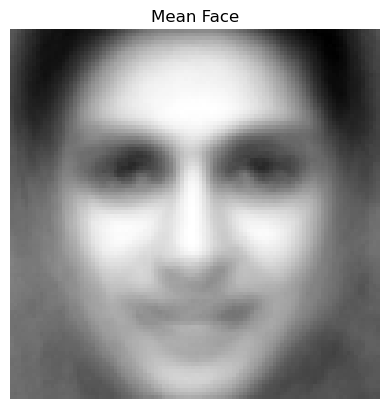

In [10]:
plt.imshow(mean_face.reshape(100,100), cmap="gray")
plt.title("Mean Face")
plt.axis("off")
plt.show()

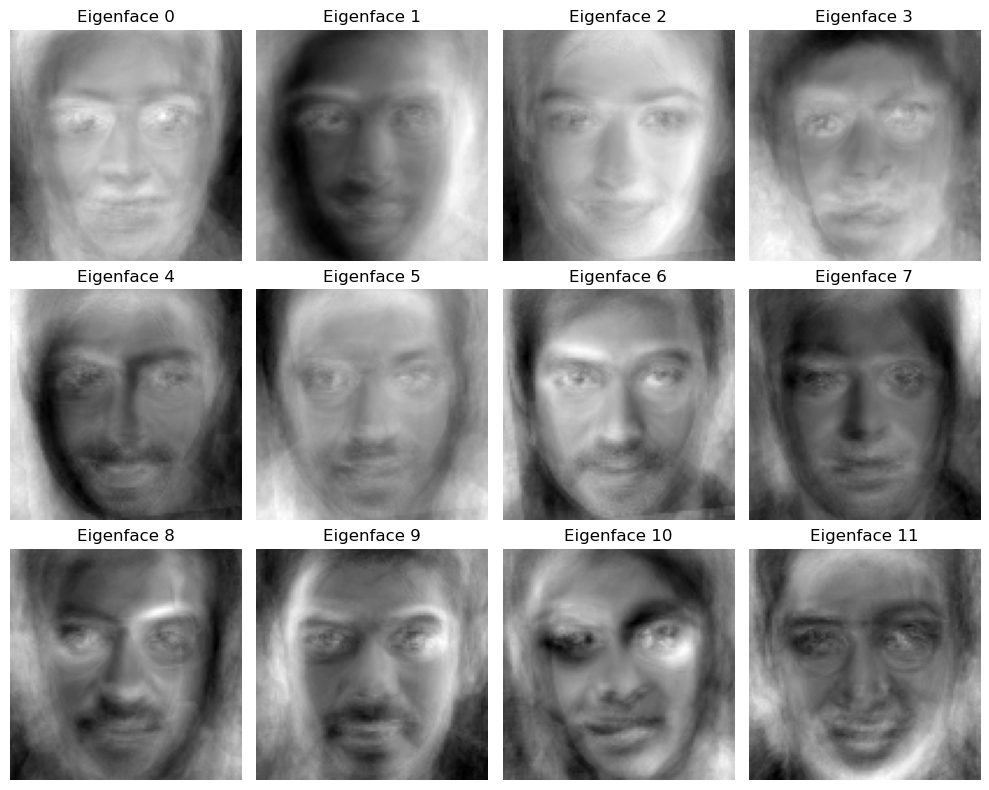

In [11]:
num_eigenfaces = 12

plt.figure(figsize=(10,8))

for i in range(num_eigenfaces):
    
    plt.subplot(3,4,i+1)
    
    face = eigenfaces[i].reshape(100,100)
    
    plt.imshow(face, cmap="gray")
    
    plt.title(f"Eigenface {i}")
    
    plt.axis("off")

plt.tight_layout()
plt.savefig("eigenfaces.png")
plt.show()

In [12]:
def get_features(X, mean_face, eigenfaces):
    
    X_centered = X - mean_face
    
    features = np.dot(eigenfaces, X_centered.T)
    
    return features.T


train_features = get_features(X_train, mean_face, eigenfaces)
test_features = get_features(X_test, mean_face, eigenfaces)

print("Feature shape:", train_features.shape)

Feature shape: (270, 100)


In [14]:
model = MLPClassifier(
    hidden_layer_sizes=(200,100),
    max_iter=1000,
    random_state=42
)

model.fit(train_features, y_train)

MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=1000, random_state=42)

In [15]:
accuracy = model.score(test_features, y_test)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.45


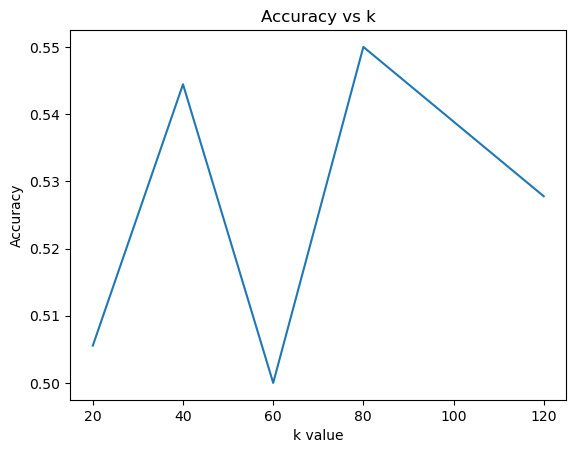

In [16]:
k_values = [20,40,60,80,100,120]
accuracies = []

for k in k_values:
    
    mean_face, eigenfaces = PCA(X_train, k)
    
    train_f = get_features(X_train, mean_face, eigenfaces)
    test_f = get_features(X_test, mean_face, eigenfaces)
    
    model_temp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
    
    model_temp.fit(train_f, y_train)
    
    acc = model_temp.score(test_f, y_test)
    
    accuracies.append(acc)

plt.plot(k_values, accuracies)

plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")

plt.savefig("accuracy_vs_k.png")

plt.show()

In [17]:
sample = test_features[0].reshape(1,-1)

prediction = model.predict(sample)

print("Predicted Person ID:", prediction[0])

Predicted Person ID: 5


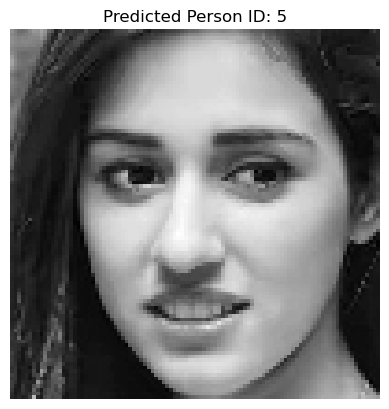

In [18]:
plt.imshow(X_test[0].reshape(100,100), cmap="gray")

plt.title(f"Predicted Person ID: {prediction[0]}")

plt.axis("off")

plt.savefig("prediction_example.png")

plt.show()

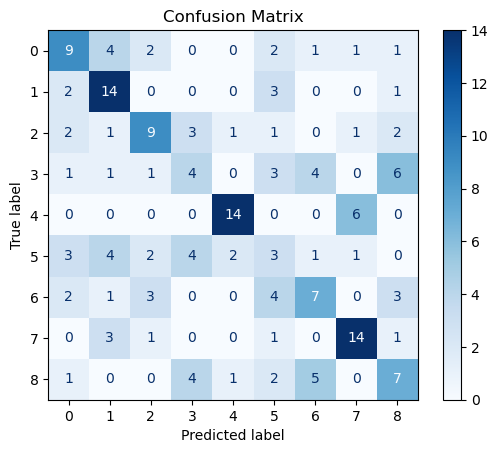

In [19]:
y_pred = model.predict(test_features)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [20]:
joblib.dump(model, "face_recognition_model.pkl")

print("Model saved successfully")

Model saved successfully
